Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 2.0.2


In [1]:
# Import relevant packages
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
# Import data from dropbox
!wget -O shopping.csv https://www.dropbox.com/scl/fi/qppn8i6xphjpue1kf3n36/shopping.csv?rlkey=qyr2x9zbnz1je4lzkx4wyaq7r&dl=0

# Import
shop_data = pd.read_csv("shopping.csv")
print(shop_data.head())

# Drop the last row which is all missing
shop_data = shop_data.iloc[:20, :]

--2025-08-13 20:04:41--  https://www.dropbox.com/scl/fi/qppn8i6xphjpue1kf3n36/shopping.csv?rlkey=qyr2x9zbnz1je4lzkx4wyaq7r
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc71902690ce44bda981f4bac46e.dl.dropboxusercontent.com/cd/0/inline/CvW-Qqyb7yUjtDMbh3iU4GfPo3iSP2F75LPSUJde5JL3gvCLcXWHcI0Wywco162Sfj4n5RFKXTzim4zOlvYvrKDOyP3z14bPJvvn4_yF7xG2Jv0TmNtMbhgdYs4xHLqGeiSBwnfRrQi5r56Sjpqnp41B/file# [following]
--2025-08-13 20:04:42--  https://uc71902690ce44bda981f4bac46e.dl.dropboxusercontent.com/cd/0/inline/CvW-Qqyb7yUjtDMbh3iU4GfPo3iSP2F75LPSUJde5JL3gvCLcXWHcI0Wywco162Sfj4n5RFKXTzim4zOlvYvrKDOyP3z14bPJvvn4_yF7xG2Jv0TmNtMbhgdYs4xHLqGeiSBwnfRrQi5r56Sjpqnp41B/file
Resolving uc71902690ce44bda981f4bac46e.dl.dropboxusercontent.com (uc71902690ce44bda981f4bac46e.dl.dropboxusercontent.com)... 162.125.5.15, 2620:1

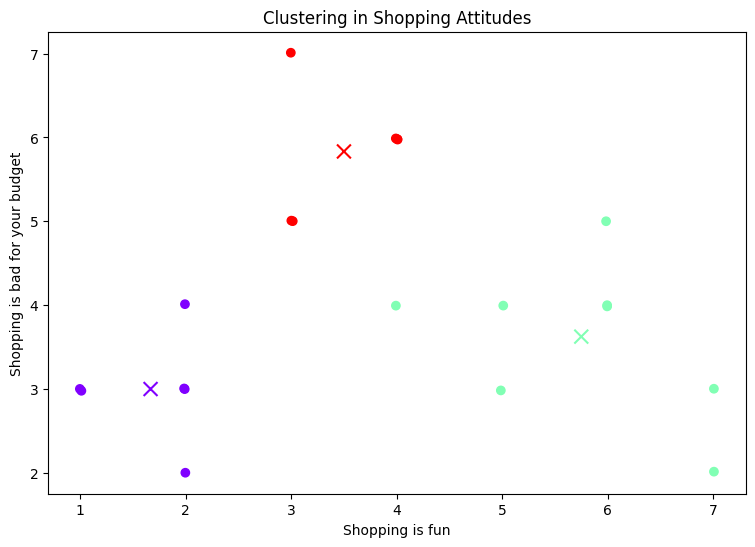

         V1        V2        V3     V4     V5        V6
0  1.666667  3.000000  1.833333  3.500  5.500  3.333333
1  5.750000  3.625000  6.000000  3.125  1.875  3.875000
2  3.500000  5.833333  3.333333  6.000  3.500  6.000000


In [4]:
# K-means with 3 clusters
X = shop_data.iloc[:, 1:7]
kmeans = KMeans(n_clusters=3, n_init=200, random_state=0).fit(X)

shop_data['cluster'] = kmeans.labels_

# Scatter plot with slight jitter
plt.figure(figsize=(9, 6))
plt.scatter(
    shop_data['V1'] + 0.01 * np.random.randn(len(shop_data)),
    shop_data['V2'] + 0.01 * np.random.randn(len(shop_data)),
    c=shop_data['cluster'],
    cmap='rainbow'
)
plt.title("Clustering in Shopping Attitudes")
plt.xlabel("Shopping is fun")
plt.ylabel("Shopping is bad for your budget")

# Plot cluster centers (only V1 and V2 dimensions)
plt.scatter(
    kmeans.cluster_centers_[:, 0],  # V1 column in X
    kmeans.cluster_centers_[:, 1],  # V2 column in X
    marker='x', s=100, c=range(3), cmap='rainbow'
)

plt.show()

# Print cluster centers
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print(centers_df)

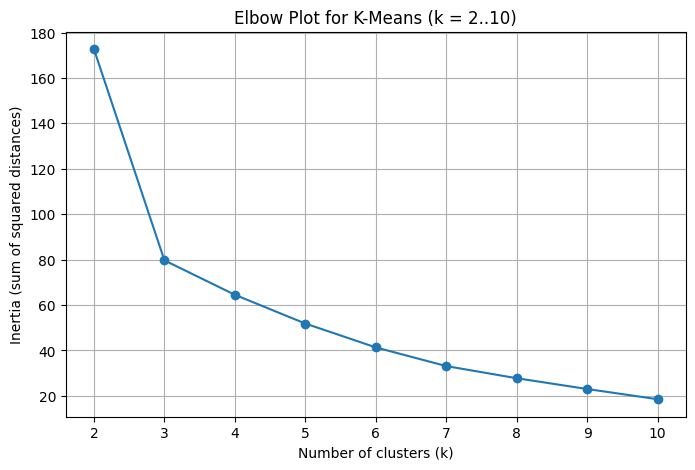

k=2: inertia=172.67
k=3: inertia=79.67
k=4: inertia=64.50
k=5: inertia=51.83
k=6: inertia=41.33
k=7: inertia=33.10
k=8: inertia=27.75
k=9: inertia=23.00
k=10: inertia=18.50


In [5]:
Ks = range(2, 11)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=200, random_state=0)
    km.fit(X)
    inertias.append(km.inertia_)  # sum of squared distances to nearest centroid

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(list(Ks), inertias, marker='o')
plt.xticks(list(Ks))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot for K-Means (k = 2..10)")
plt.grid(True)
plt.show()

for k, sse in zip(Ks, inertias):
    print(f"k={k}: inertia={sse:,.2f}")